# ECE 671 Final Project - QUIC vs TCP on FABRIC


# Setup

In [ ]:
# import libraries for fabric setup, remote commands, parsing results, and plotting
from fabrictestbed_extensions.fablib.fablib import FablibManager

import json
import time
import re
import base64
import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import matplotlib.pyplot as plt

fablib = FablibManager()    # create fabric manager
_ = fablib.show_config()    # verify fabric login and project config

all_results = []    # store tcp and quic trial results

User: mla@umass.edu bastion key is valid!
Configuration is valid


Credential Manager,cm.fabric-testbed.net
Orchestrator,orchestrator.fabric-testbed.net
Project ID,5268932f-7bf8-4418-9dbb-1f53dcea5a6b
Token File,/home/fabric/.tokens.json
Bastion Host,bastion.fabric-testbed.net
Bastion Username,mla_0000467888
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Private Key File,/home/fabric/work/fabric_config/slice_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub
Log File,/tmp/fablib/fablib.log
Log Level,INFO


# Project Configuration

In [ ]:
# define experiment settings and the two fabric paths

project_name = "ece671_quic_tcp" 
timestamp = datetime.datetime.now().strftime("%m%d_%H%M")  # make unique file and slice names

node_image = "default_ubuntu_22"
node_cores = 2  # cpu cores per node
node_ram = 4  # ram in gb per node
node_disk = 10  # disk in gb per node

loss_levels = [0, 2, 5]  # baseline, moderate loss, high loss
trials_per_condition = 3  # repeat each condition 3 times
test_duration_seconds = 10  # unused leftover from an earlier duration-based plan

iperf_port = 5201  # tcp iperf3 server port
quic_port = 4433  # quic server port

remote_quic_script = "/home/ubuntu/quic_perf_test.py"  # QUIC script location on each node

path_configs = [
    {
        "path_name": "MASS_NEWY",  # short regional path
        "client_site": "MASS",
        "server_site": "NEWY",
        "slice_name": f"{project_name}_MASS_NEWY_{timestamp}",
        "client_ip": "10.10.1.1",
        "server_ip": "10.10.1.2",
        "subnet_prefix": "24",
    },
    {
        "path_name": "MASS_UCSD",  # long cross-country path
        "client_site": "MASS",
        "server_site": "UCSD",
        "slice_name": f"{project_name}_MASS_UCSD_{timestamp}",
        "client_ip": "10.10.2.1",
        "server_ip": "10.10.2.2",
        "subnet_prefix": "24",
    },
]

# Create FABRIC slices

In [ ]:
def create_path_slice(path_config): # create one FABRIC slice with a client node and a server node

    slice_object = fablib.new_slice(name=path_config["slice_name"])  # create an empty slice

    # create client node
    client_node = slice_object.add_node(
        name="client",
        site=path_config["client_site"],
        image=node_image,
        cores=node_cores,
        ram=node_ram,
        disk=node_disk,
    )  

    # create server node
    server_node = slice_object.add_node(
        name="server",
        site=path_config["server_site"],
        image=node_image,
        cores=node_cores,
        ram=node_ram,
        disk=node_disk,
    )  

    # add client data NIC
    client_interface = client_node.add_component(
        model="NIC_Basic",
        name="client_nic",
    ).get_interfaces()[0]

    # add server data NIC
    server_interface = server_node.add_component(
        model="NIC_Basic",
        name="server_nic",
    ).get_interfaces()[0]

    # create site to site Layer 2 network between the two sites
    slice_object.add_l2network(
        name="data_net",
        interfaces=[client_interface, server_interface],
        type="L2STS",
    )

    return slice_object  # return the slice definition


slice_objects = {}  # store slice objects

for path_config in path_configs:
    path_name = path_config["path_name"]  # get path label
    slice_objects[path_name] = create_path_slice(path_config)  # create one path slice

# Submit Slices

In [ ]:
def submit_and_wait_for_slice(path_config): # submit one slice and wait until ssh is ready
    
    path_name = path_config["path_name"]  # get path label
    slice_object = slice_objects[path_name]  # get matching slice object

    print(f"Submitting {path_config['slice_name']}")  
    slice_object.submit(progress=True)  # submit slice request to fabric

    print(f"Waiting for SSH on {path_name}") 

    try:
        slice_object.wait_ssh(progress=True)  # wait until nodes are reachable
    except TypeError:
        slice_object.wait_ssh()  # fallback for older fablib versions

    try:
        slice_object.post_boot_config()  # run postboot config if needed
    except Exception:
        pass  # continue if already configured or unsupported

    return path_name  # return completed path name


with ThreadPoolExecutor(max_workers=len(path_configs)) as executor:
    futures = [
        executor.submit(submit_and_wait_for_slice, path_config)
        for path_config in path_configs
    ]  # submit both slices at the same time

    for future in as_completed(futures):
        future.result()  # raise any error if slice submission failed


for path_config in path_configs:
    path_name = path_config["path_name"]  # get path label
    slice_objects[path_name] = fablib.get_slice(name=path_config["slice_name"])  # refresh slice handle


Retry: 10, Time: 242 sec


ID,bdcc9a00-ab89-48e7-8d5e-7029978b3ec7
Name,ece671_quic_tcp_MASS_UCSD_0510_0530
Lease Expiration (UTC),2026-05-11 05:30:42 +0000
Lease Start (UTC),2026-05-10 05:30:42 +0000
Project ID,5268932f-7bf8-4418-9dbb-1f53dcea5a6b
State,StableOK
Email,mla@umass.edu
UserId,d74e2395-f149-45bb-9c7e-f23cf8927e22


ID,Name,Cores,RAM,Disk,Image,Image Type,Host,Site,Username,Management IP,State,Error,SSH Command,Public SSH Key File,Private SSH Key File
1b38c9da-2c24-47a8-9299-074862f130db,client,2,4,10,default_ubuntu_22,qcow2,mass-w3.fabric-testbed.net,MASS,ubuntu,2001:48e8:6401:3:f816:3eff:fed1:45f3,Active,,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:48e8:6401:3:f816:3eff:fed1:45f3,/home/fabric/work/fabric_config/slice_key.pub,/home/fabric/work/fabric_config/slice_key
6fe603b9-1b95-4d36-bdcc-6724b67c7ee1,server,2,4,10,default_ubuntu_22,qcow2,ucsd-w2.fabric-testbed.net,UCSD,ubuntu,2001:48d0:6031:1991:f816:3eff:fe16:fb2f,Active,,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:48d0:6031:1991:f816:3eff:fe16:fb2f,/home/fabric/work/fabric_config/slice_key.pub,/home/fabric/work/fabric_config/slice_key


ID,Name,Layer,Type,Site,Subnet,Gateway,State,Error
76278690-0988-4973-a83f-5060030946ce,data_net,L2,L2STS,None,None,None,Active,


Name,Short Name,Node,Network,Bandwidth,Mode,VLAN,MAC,Physical Device,Device,IP Address,Numa Node,Switch Port
client-client_nic-p1,p1,client,data_net,100,config,,46:AE:AA:AA:B2:FD,enp7s0,enp7s0,fe80::44ae:aaff:feaa:b2fd,4,HundredGigE0/0/0/13
server-server_nic-p1,p1,server,data_net,100,config,,0E:62:1A:D6:09:B9,enp7s0,enp7s0,fe80::c62:1aff:fed6:9b9,4,HundredGigE0/0/0/7



Time to print interfaces 242 seconds
Waiting for SSH on MASS_NEWY
Waiting for slice . Slice state: StableOK
Waiting for ssh in slice .

Name,Short Name,Node,Network,Bandwidth,Mode,VLAN,MAC,Physical Device,Device,IP Address,Numa Node,Switch Port
client-client_nic-p1,p1,client,data_net,100,config,,46:FA:E8:B0:2D:66,enp7s0,enp7s0,fe80::44fa:e8ff:feb0:2d66,4,HundredGigE0/0/0/13
server-server_nic-p1,p1,server,data_net,100,config,,1A:ED:2C:A5:7D:13,enp7s0,enp7s0,fe80::18ed:2cff:fea5:7d13,6,HundredGigE0/0/0/7



Time to print interfaces 246 seconds
Waiting for SSH on MASS_UCSD
 ssh successful
Waiting for slice . Slice state: StableOK
Waiting for ssh in slice .Running post boot config threads ...
 ssh successful
Post boot config server, Done! (6 sec)
Post boot config client, Done! (6 sec)
Saving fablib data... Running post boot config threads ...
 Done!
Post boot config client, Done! (5 sec)
Post boot config server, Done! (6 sec)
Saving fablib data...  Done!


# Nodes Preparation

In [ ]:
# define the quic client and server script

quic_script_text = r'''
#!/usr/bin/env python3

import argparse
import asyncio
import json
import ssl
import time

from aioquic.asyncio import connect, serve
from aioquic.quic.configuration import QuicConfiguration


def make_configuration(is_client):  # create quic config
    configuration = QuicConfiguration(is_client=is_client, alpn_protocols=["perf"])
    configuration.max_data = 256 * 1024 * 1024
    configuration.max_stream_data = 256 * 1024 * 1024
    return configuration


def handle_stream(reader, writer):  # start async handler for each quic stream
    asyncio.create_task(handle_stream_worker(reader, writer))


async def handle_stream_worker(reader, writer):  # receive payload and report throughput
    header_line = await reader.readline()  # read expected byte count
    header = json.loads(header_line.decode())  # parse header json
    expected_bytes = int(header["bytes"])  # get expected bytes

    received_bytes = 0
    start_time = time.time()

    while received_bytes < expected_bytes:
        data = await reader.read(min(65536, expected_bytes - received_bytes))  # read data chunk

        if not data:
            break

        received_bytes += len(data)

    elapsed = max(time.time() - start_time, 1e-9)

    result = {
        "bytes_received": received_bytes,
        "server_duration_seconds": elapsed,
        "throughput_mbps": (received_bytes * 8) / elapsed / 1_000_000,
    }

    writer.write(json.dumps(result).encode())  # send result json to client
    writer.write_eof()
    await writer.drain()


async def run_server(args):  # run quic server
    configuration = make_configuration(is_client=False)
    configuration.load_cert_chain(args.cert, args.key)

    await serve(
        args.host,
        args.port,
        configuration=configuration,
        stream_handler=handle_stream,
    )

    await asyncio.Event().wait()


async def run_client(args):  # run quic client
    configuration = make_configuration(is_client=True)
    configuration.verify_mode = ssl.CERT_NONE   # accept self-signed test certificate

    total_bytes = args.bytes_mb * 1024 * 1024

    async with connect(args.host, args.port, configuration=configuration) as protocol:
        reader, writer = await protocol.create_stream()

        header = json.dumps({"bytes": total_bytes}).encode() + b"\n"
        writer.write(header)    # tell server how many bytes to expect
        await writer.drain()

        payload = b"x" * args.chunk_size
        bytes_sent = 0
        start_time = time.time()

        while bytes_sent < total_bytes:
            bytes_left = total_bytes - bytes_sent
            current_payload = payload[:min(args.chunk_size, bytes_left)]

            writer.write(current_payload)   # send one payload chunk
            await writer.drain()

            bytes_sent += len(current_payload)

        writer.write_eof()
        await writer.drain()

        raw_result = await asyncio.wait_for(reader.read(65536), timeout=args.timeout)   # wait for server result
        finish_time = time.time()

        server_result = json.loads(raw_result.decode())
        client_duration = max(finish_time - start_time, 1e-9)

        result = {
            "protocol": "QUIC",
            "bytes_sent": bytes_sent,
            "client_duration_seconds": client_duration,
            "client_throughput_mbps": (bytes_sent * 8) / client_duration / 1_000_000,
        }

        result.update(server_result)

        print(json.dumps(result))


def main():  # parse command line arguments
    parser = argparse.ArgumentParser()

    parser.add_argument("--mode", choices=["server", "client"], required=True)
    parser.add_argument("--host", default="0.0.0.0")
    parser.add_argument("--port", type=int, default=4433)
    parser.add_argument("--bytes-mb", type=int, default=16)
    parser.add_argument("--chunk-size", type=int, default=16384)
    parser.add_argument("--timeout", type=int, default=60)
    parser.add_argument("--cert", default="/home/ubuntu/quic_cert.pem")
    parser.add_argument("--key", default="/home/ubuntu/quic_key.pem")

    args = parser.parse_args()

    if args.mode == "server":
        asyncio.run(run_server(args))
    else:
        asyncio.run(run_client(args))


if __name__ == "__main__":
    main()
'''

# copy the quic script to both paths and run 8 mb validation test

for path_config in path_configs:
    path_name = path_config["path_name"]
    slice_object = slice_objects[path_name]

    client_node = slice_object.get_node(name="client")
    server_node = slice_object.get_node(name="server")
    server_ip = path_config["server_ip"]

    client_interface_name = get_data_interface_name(client_node)
    clear_packet_loss(client_node, client_interface_name)  # clear old loss before debug test

    print(f"\nupdating quic script on {path_name}", flush=True)

    write_remote_file(client_node, remote_quic_script, quic_script_text)  # copy script to client
    write_remote_file(server_node, remote_quic_script, quic_script_text)  # copy script to server

    server_node.execute("pkill -f 'quic_perf_test.py --mode server' || true", quiet=True)  # stop old quic server

    # create temporary quic certificate
    server_node.execute(
        "openssl req -x509 -newkey rsa:2048 "
        "-keyout /home/ubuntu/quic_key.pem "
        "-out /home/ubuntu/quic_cert.pem "
        "-days 2 "
        "-nodes "
        "-subj '/CN=fabric-quic-test'",
        quiet=True,
    )

    # start quic server in background
    server_node.execute(
        f"nohup python3 -u {remote_quic_script} "
        f"--mode server "
        f"--host 0.0.0.0 "
        f"--port {quic_port} "
        f"--cert /home/ubuntu/quic_cert.pem "
        f"--key /home/ubuntu/quic_key.pem "
        f"> /tmp/quic_server.log 2>&1 &",
        quiet=True,
    )

    time.sleep(2)   # give server time to start

    # run 8 mb quic validation test
    stdout, stderr = client_node.execute(
        f"timeout 80 python3 {remote_quic_script} "
        f"--mode client "
        f"--host {server_ip} "
        f"--port {quic_port} "
        f"--bytes-mb 8 "
        f"--chunk-size 16384 "
        f"--timeout 60; echo exit_code:$?",
        quiet=True,
    )

    print("client stdout:")
    print(stdout if stdout.strip() else "empty stdout")

    print("client stderr:")
    print(stderr if stderr.strip() else "empty stderr")

    stdout, stderr = server_node.execute("tail -30 /tmp/quic_server.log", quiet=True)  # check quic server log
    print("server log:")
    print(stdout if stdout.strip() else "server log is empty")


updating quic script on MASS_NEWY
client stdout:
{"protocol": "QUIC", "bytes_sent": 8388608, "client_duration_seconds": 0.6002974510192871, "client_throughput_mbps": 111.79268525303773, "bytes_received": 8388608, "server_duration_seconds": 0.5901317596435547, "throughput_mbps": 113.71844152318526}
exit_code:0

client stderr:
empty stderr
server log:
server log is empty

updating quic script on MASS_UCSD
client stdout:
{"protocol": "QUIC", "bytes_sent": 8388608, "client_duration_seconds": 1.4501523971557617, "client_throughput_mbps": 46.27711137920617, "bytes_received": 8388608, "server_duration_seconds": 1.372950553894043, "throughput_mbps": 48.87930145019564}
exit_code:0

client stderr:
empty stderr
server log:
server log is empty


# Configure Interfaces and Start Servers

In [ ]:
def get_data_interface_name(node):  # find linux interface name for fabric data nic

    for interface in node.get_interfaces():
        try:
            linux_interface_name = interface.get_os_interface() # get os-level interface name
        except Exception:
            linux_interface_name = None

        if linux_interface_name:
            return linux_interface_name # return first valid data interface

    stdout, stderr = node.execute("ip -brief addr", quiet=True)
    print(stdout)

    raise RuntimeError(f"could not find data interface on {node.get_name()}")


def configure_data_interfaces(path_config): # assign manual IPv4 addresses to the l2sts interfaces

    slice_object = slice_objects[path_config["path_name"]]

    client_node = slice_object.get_node(name="client")
    server_node = slice_object.get_node(name="server")

    client_interface_name = get_data_interface_name(client_node)   # get client data nic
    server_interface_name = get_data_interface_name(server_node)   # get server data nic

    client_ip = path_config["client_ip"]
    server_ip = path_config["server_ip"]
    subnet_prefix = path_config["subnet_prefix"]

    client_node.execute(f"sudo ip addr flush dev {client_interface_name} || true", quiet=True)
    server_node.execute(f"sudo ip addr flush dev {server_interface_name} || true", quiet=True)

    # assign client ip
    client_node.execute(
        f"sudo ip addr add {client_ip}/{subnet_prefix} dev {client_interface_name}",
        quiet=True,
    )   

    # assign server ip
    server_node.execute(
        f"sudo ip addr add {server_ip}/{subnet_prefix} dev {server_interface_name}",
        quiet=True,
    )

    client_node.execute(f"sudo ip link set {client_interface_name} up", quiet=True) # remove old client ip
    server_node.execute(f"sudo ip link set {server_interface_name} up", quiet=True) # remove old server ip

    print(f"{path_config['path_name']}: ping test to {server_ip}")

    stdout, stderr = client_node.execute(f"ping -c 3 {server_ip}", quiet=True)  # verify client-to-server path
    print(stdout)


def stop_servers(server_node): # stop old tcp and quic servers

    server_node.execute("pkill -f 'iperf3 -s' || true", quiet=True) # stop old iperf3 server
    server_node.execute("pkill -f 'quic_perf_test.py --mode server' || true", quiet=True)  # stop old quic server


def start_servers(server_node):  # start tcp and quic servers

    stop_servers(server_node)   # clear old server processes first

    # start tcp server in background
    server_node.execute(
        f"nohup iperf3 -s -p {iperf_port} > /tmp/iperf3_server.log 2>&1 &",
        quiet=True,
    )

    # create temporary quic certificate
    server_node.execute(
        """
openssl req -x509 -newkey rsa:2048 \
    -keyout /home/ubuntu/quic_key.pem \
    -out /home/ubuntu/quic_cert.pem \
    -days 2 \
    -nodes \
    -subj '/CN=fabric-quic-test'
""",
        quiet=True,
    )

    # start quic server in background
    server_node.execute(
        f"nohup python3 {remote_quic_script} "
        f"--mode server "
        f"--host 0.0.0.0 "
        f"--port {quic_port} "
        f"--cert /home/ubuntu/quic_cert.pem "
        f"--key /home/ubuntu/quic_key.pem "
        f"> /tmp/quic_server.log 2>&1 &",
        quiet=True,
    )

    time.sleep(2)  # give servers time to start


for path_config in path_configs:
    configure_data_interfaces(path_config) # configure data path for each slice

MASS_NEWY: ping test to 10.10.1.2
PING 10.10.1.2 (10.10.1.2) 56(84) bytes of data.
64 bytes from 10.10.1.2: icmp_seq=1 ttl=64 time=9.38 ms
64 bytes from 10.10.1.2: icmp_seq=2 ttl=64 time=4.68 ms
64 bytes from 10.10.1.2: icmp_seq=3 ttl=64 time=4.67 ms

--- 10.10.1.2 ping statistics ---
3 packets transmitted, 3 received, 0% packet loss, time 2003ms
rtt min/avg/max/mdev = 4.665/6.241/9.379/2.218 ms

MASS_UCSD: ping test to 10.10.2.2
PING 10.10.2.2 (10.10.2.2) 56(84) bytes of data.
64 bytes from 10.10.2.2: icmp_seq=1 ttl=64 time=143 ms
64 bytes from 10.10.2.2: icmp_seq=2 ttl=64 time=71.6 ms
64 bytes from 10.10.2.2: icmp_seq=3 ttl=64 time=71.5 ms

--- 10.10.2.2 ping statistics ---
3 packets transmitted, 3 received, 0% packet loss, time 2003ms
rtt min/avg/max/mdev = 71.543/95.425/143.182/33.768 ms



# Run Experiments

In [ ]:
# run tcp and quic transfers for each path, loss level, and trial

transfer_size_mb = 8  # fixed payload size for tcp and quic


def clear_packet_loss(node, interface_name):  # remove artificial packet loss
    node.execute(
        f"sudo tc qdisc del dev {interface_name} root || true",
        quiet=True,
    )


def apply_packet_loss(node, interface_name, loss_percent): # apply outbound packet loss on client nic
    if loss_percent == 0:
        clear_packet_loss(node, interface_name)  # use normal queueing at 0% loss
    else:
        node.execute(
            f"sudo tc qdisc replace dev {interface_name} root netem loss {loss_percent}%",
            quiet=True,
        )   # apply selected netem loss rate

    time.sleep(1)   # give qdisc change time to apply


def show_qdisc(node, interface_name):  # print active queueing rule
    stdout, stderr = node.execute(
        f"tc qdisc show dev {interface_name}",
        quiet=True,
    )

    qdisc_text = stdout.strip()

    if qdisc_text:
        print("    qdisc:")
        for line in qdisc_text.splitlines():
            print(f"      {line}")


def extract_json_object(output_text):  # extract json object from command output
    start_index = output_text.find("{")
    end_index = output_text.rfind("}")

    if start_index == -1 or end_index == -1:
        raise ValueError(f"no json found in output:\n{output_text}")

    return json.loads(output_text[start_index:end_index + 1])


def measure_latency_ms(client_node, server_ip):  # measure average rtt with ping
    stdout, stderr = client_node.execute(
        f"ping -c 5 {server_ip}",
        quiet=True,
    )

    match = re.search(r"rtt .* = [\d.]+/([\d.]+)/", stdout)

    if match:
        return float(match.group(1))

    return None


def format_throughput(throughput_mbps):  # format throughput for progress output
    if throughput_mbps is None:
        return "none"

    return f"{throughput_mbps:.2f} mbps"


def format_latency(latency_ms):  # format latency for progress output
    if latency_ms is None:
        return "none"

    return f"{latency_ms:.2f} ms"


def run_tcp_test(client_node, server_ip):  # run one tcp fixed-size transfer
    command = f"iperf3 -c {server_ip} -p {iperf_port} -n {transfer_size_mb}M -J"   # use json output

    stdout, stderr = client_node.execute(command, quiet=True)

    iperf_data = extract_json_object(stdout)    # parse iperf3 json
    end_data = iperf_data.get("end", {})

    sum_received = end_data.get("sum_received", {})
    sum_sent = end_data.get("sum_sent", {})

    bits_per_second = sum_received.get(
        "bits_per_second",
        sum_sent.get("bits_per_second", None),
    )

    throughput_mbps = bits_per_second / 1_000_000 if bits_per_second else None
    retransmits = sum_sent.get("retransmits", None) # get tcp retransmission count

    return {
        "protocol": "TCP",
        "throughput_mbps": throughput_mbps,
        "tcp_retransmits": retransmits,
        "bytes_received": sum_received.get("bytes", None),
        "transfer_size_mb": transfer_size_mb,
        "error": "",
    }


def run_quic_test(client_node, server_ip):  # run one quic fixed-size transfer
    command = (
        f"timeout 180 python3 {remote_quic_script} "
        f"--mode client "
        f"--host {server_ip} "
        f"--port {quic_port} "
        f"--bytes-mb {transfer_size_mb} "
        f"--chunk-size 16384 "
        f"--timeout 160"
    )   # allow slow high-loss quic trials to finish

    stdout, stderr = client_node.execute(command, quiet=True)

    if not stdout.strip():
        raise RuntimeError(f"quic stdout empty\nstderr:\n{stderr}")

    quic_data = extract_json_object(stdout) # parse quic json output

    # use server throughput if available
    throughput_mbps = quic_data.get(
        "throughput_mbps",
        quic_data.get("client_throughput_mbps", None),
    )

    return {
        "protocol": "QUIC",
        "throughput_mbps": throughput_mbps,
        "tcp_retransmits": None,
        "bytes_received": quic_data.get("bytes_received", None),
        "transfer_size_mb": transfer_size_mb,
        "error": "",
    }


def add_result_metadata(result, path_config, loss_percent, trial_number, latency_ms):  # attach trial metadata
    result.update({
        "path_name": path_config["path_name"],
        "client_site": path_config["client_site"],
        "server_site": path_config["server_site"],
        "loss_percent": loss_percent,
        "trial_number": trial_number,
        "latency_ms": latency_ms,
        "client_ip": path_config["client_ip"],
        "server_ip": path_config["server_ip"],
        "timestamp": datetime.datetime.now().isoformat(),
    })

    return result


def run_experiments_for_path(path_config, path_index, total_paths):  # run all tests for one path
    path_name = path_config["path_name"]
    slice_object = slice_objects[path_name]

    client_node = slice_object.get_node(name="client")
    server_node = slice_object.get_node(name="server")

    client_interface_name = get_data_interface_name(client_node)    # get client data nic
    client_ip = path_config["client_ip"]
    server_ip = path_config["server_ip"]

    print(f"\n[path {path_index}/{total_paths}] {path_name}: {client_ip} -> {server_ip}", flush=True)

    start_servers(server_node)  # start tcp and quic servers

    path_results = []

    try:
        for loss_index, loss_percent in enumerate(loss_levels, start=1):
            print(f"\n  [loss {loss_index}/{len(loss_levels)}] {loss_percent}%", flush=True)

            apply_packet_loss(client_node, client_interface_name, loss_percent) # set current loss level
            show_qdisc(client_node, client_interface_name)  # confirm qdisc setting

            for trial_number in range(1, trials_per_condition + 1):
                print(f"    trial {trial_number}/{trials_per_condition}", flush=True)

                latency_ms = measure_latency_ms(client_node, server_ip) # measure rtt before trial
                print(f"      latency: {format_latency(latency_ms)}", flush=True)

                try:
                    tcp_result = run_tcp_test(client_node, server_ip)   # run tcp transfer
                    tcp_throughput = format_throughput(tcp_result["throughput_mbps"])
                    tcp_retransmits = tcp_result["tcp_retransmits"]

                    print(
                        f"      tcp done: {tcp_throughput}, retransmits={tcp_retransmits}",
                        flush=True,
                    )

                except Exception as error:
                    tcp_result = {
                        "protocol": "TCP",
                        "throughput_mbps": None,
                        "tcp_retransmits": None,
                        "bytes_received": None,
                        "transfer_size_mb": transfer_size_mb,
                        "error": str(error),
                    }

                    print(f"      tcp failed: {error}", flush=True)

                # add path, loss, trial, and latency info
                tcp_result = add_result_metadata(
                    result=tcp_result,
                    path_config=path_config,
                    loss_percent=loss_percent,
                    trial_number=trial_number,
                    latency_ms=latency_ms,
                )

                path_results.append(tcp_result)

                time.sleep(1)   # small gap between protocol tests

                try:
                    quic_result = run_quic_test(client_node, server_ip) # run quic transfer
                    quic_throughput = format_throughput(quic_result["throughput_mbps"])

                    print(
                        f"      quic done: {quic_throughput}",
                        flush=True,
                    )

                except Exception as error:
                    quic_result = {
                        "protocol": "QUIC",
                        "throughput_mbps": None,
                        "tcp_retransmits": None,
                        "bytes_received": None,
                        "transfer_size_mb": transfer_size_mb,
                        "error": str(error),
                    }

                    print(f"      quic failed: {error}", flush=True)

                # add path, loss, trial, and latency info
                quic_result = add_result_metadata(
                    result=quic_result,
                    path_config=path_config,
                    loss_percent=loss_percent,
                    trial_number=trial_number,
                    latency_ms=latency_ms,
                )

                path_results.append(quic_result)

                time.sleep(1)   # small gap before next trial

    finally:
        clear_packet_loss(client_node, client_interface_name)   # remove loss rule after path tests
        stop_servers(server_node)   # stop background servers

    return path_results


all_results = []   # store all trial results

for path_index, path_config in enumerate(path_configs, start=1):
    path_results = run_experiments_for_path(
        path_config=path_config,
        path_index=path_index,
        total_paths=len(path_configs),
    )

    all_results.extend(path_results)    # add path results to final result list


[path 1/2] MASS_NEWY: 10.10.1.1 -> 10.10.1.2

  [loss 1/3] 0%
    qdisc:
      qdisc mq 0: root 
      qdisc fq_codel 0: parent :2 limit 10240p flows 1024 quantum 1514 target 5ms interval 100ms memory_limit 32Mb ecn drop_batch 64 
      qdisc fq_codel 0: parent :1 limit 10240p flows 1024 quantum 1514 target 5ms interval 100ms memory_limit 32Mb ecn drop_batch 64
    trial 1/3
      latency: 4.67 ms
      tcp done: 439.56 mbps, retransmits=0
      quic done: 114.24 mbps
    trial 2/3
      latency: 4.66 ms
      tcp done: 629.74 mbps, retransmits=172
      quic done: 123.24 mbps
    trial 3/3
      latency: 4.67 ms
      tcp done: 713.12 mbps, retransmits=0
      quic done: 121.67 mbps

  [loss 2/3] 2%
    qdisc:
      qdisc netem 8003: root refcnt 17 limit 1000 loss 2%
    trial 1/3
      latency: 4.68 ms
      tcp done: 478.18 mbps, retransmits=62
      quic done: 14.09 mbps
    trial 2/3
      latency: 4.66 ms
      tcp done: 501.11 mbps, retransmits=45
      quic done: 13.57 mbps
  

# Results

In [ ]:
# save raw trial results and create averaged summary tables

results_dataframe = pd.DataFrame(all_results)  # convert results list to table

raw_results_file = f"quic_tcp_fabric_raw_results_{timestamp}.csv"  # raw csv file name
summary_results_file = f"quic_tcp_fabric_summary_{timestamp}.csv"  # summary csv file name

results_dataframe.to_csv(raw_results_file, index=False)  # save every trial result

# keep only successful rows
clean_results_dataframe = results_dataframe[
    (results_dataframe["error"] == "") &
    (results_dataframe["throughput_mbps"].notna())
].copy()  

summary_dataframe = clean_results_dataframe.groupby(
    ["path_name", "client_site", "server_site", "protocol", "loss_percent"],
    as_index=False,
).agg(
    avg_throughput_mbps=("throughput_mbps", "mean"),  # average throughput
    std_throughput_mbps=("throughput_mbps", "std"),  # throughput variation
    avg_latency_ms=("latency_ms", "mean"),  # average latency
    avg_tcp_retransmits=("tcp_retransmits", "mean"),  # average tcp retransmits
    trials=("trial_number", "count"),  # successful trial count
)

summary_dataframe.to_csv(summary_results_file, index=False)  # save summary results

print("total rows:", len(results_dataframe))  # check total rows
print("successful rows:", len(clean_results_dataframe))  # check successful rows
print("error rows:", len(results_dataframe) - len(clean_results_dataframe)) # check failed rows
print("raw results:", raw_results_file)
print("summary results:", summary_results_file)

display(results_dataframe)
display(summary_dataframe)

total rows: 36
successful rows: 36
error rows: 0
raw results: quic_tcp_fabric_raw_results_0510_0530.csv
summary results: quic_tcp_fabric_summary_0510_0530.csv


,protocol,throughput_mbps,tcp_retransmits,bytes_received,transfer_size_mb,error,path_name,client_site,server_site,loss_percent,trial_number,latency_ms,client_ip,server_ip,timestamp
0,TCP,439.564718,0.0,5111808,8,,MASS_NEWY,MASS,NEWY,0,1,4.672,10.10.1.1,10.10.1.2,2026-05-10T06:18:03.690070
1,QUIC,114.244108,NaN,8388608,8,,MASS_NEWY,MASS,NEWY,0,1,4.672,10.10.1.1,10.10.1.2,2026-05-10T06:18:06.704247
2,TCP,629.736912,172.0,7733248,8,,MASS_NEWY,MASS,NEWY,0,2,4.656,10.10.1.1,10.10.1.2,2026-05-10T06:18:13.774544
3,QUIC,123.244799,NaN,8388608,8,,MASS_NEWY,MASS,NEWY,0,2,4.656,10.10.1.1,10.10.1.2,2026-05-10T06:18:17.137161
4,TCP,713.118189,0.0,7995392,8,,MASS_NEWY,MASS,NEWY,0,3,4.665,10.10.1.1,10.10.1.2,2026-05-10T06:18:24.449807
5,QUIC,121.669347,NaN,8388608,8,,MASS_NEWY,MASS,NEWY,0,3,4.665,10.10.1.1,10.10.1.2,2026-05-10T06:18:27.283225
6,TCP,478.178740,62.0,5373952,8,,MASS_NEWY,MASS,NEWY,2,1,4.679,10.10.1.1,10.10.1.2,2026-05-10T06:18:37.574127
7,QUIC,14.086855,NaN,8388608,8,,MASS_NEWY,MASS,NEWY,2,1,4.679,10.10.1.1,10.10.1.2,2026-05-10T06:18:44.747607
8,TCP,501.114374,45.0,5636096,8,,MASS_NEWY,MASS,NEWY,2,2,4.664,10.10.1.1,10.10.1.2,2026-05-10T06:18:52.222687
9,QUIC,13.566092,NaN,8388608,8,,MASS_NEWY,MASS,NEWY,2,2,4.664,10.10.1.1,10.10.1.2,2026-05-10T06:18:59.423811


,path_name,client_site,server_site,protocol,loss_percent,avg_throughput_mbps,std_throughput_mbps,avg_latency_ms,avg_tcp_retransmits,trials
0,MASS_NEWY,MASS,NEWY,QUIC,0,119.719418,4.806743,4.664333,NaN,3
1,MASS_NEWY,MASS,NEWY,QUIC,2,13.517759,0.594737,4.669000,NaN,3
2,MASS_NEWY,MASS,NEWY,QUIC,5,7.489546,0.119700,4.673000,NaN,3
3,MASS_NEWY,MASS,NEWY,TCP,0,594.139940,140.207823,4.664333,57.333333,3
4,MASS_NEWY,MASS,NEWY,TCP,2,577.278088,152.214870,4.669000,50.666667,3
5,MASS_NEWY,MASS,NEWY,TCP,5,15.679411,1.849684,4.673000,253.333333,3
6,MASS_UCSD,MASS,UCSD,QUIC,0,55.477392,7.214224,71.565333,NaN,3
7,MASS_UCSD,MASS,UCSD,QUIC,2,1.085745,0.043710,71.584333,NaN,3
8,MASS_UCSD,MASS,UCSD,QUIC,5,0.629558,0.017615,71.576333,NaN,3
9,MASS_UCSD,MASS,UCSD,TCP,0,71.823998,3.983198,71.565333,0.000000,3


saved: throughput_vs_loss_MASS_NEWY_0510_0530.png


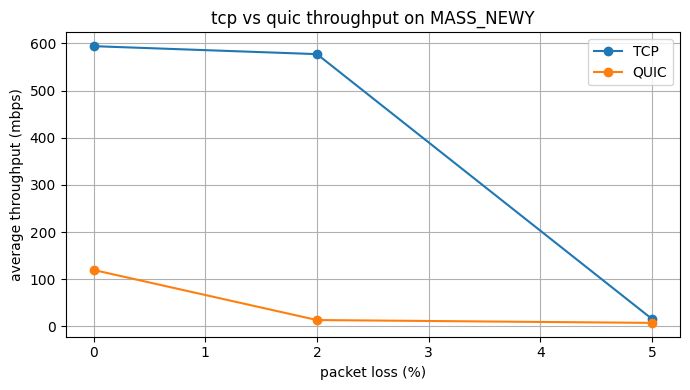

saved: throughput_vs_loss_MASS_UCSD_0510_0530.png


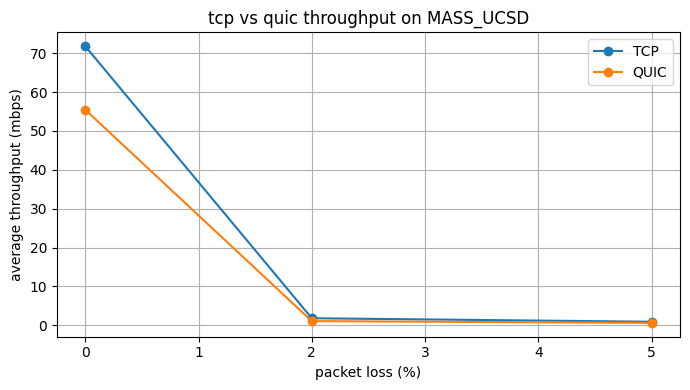

In [ ]:
# plot average tcp and quic throughput versus packet loss for each path

for path_name in summary_dataframe["path_name"].unique():
    path_summary = summary_dataframe[summary_dataframe["path_name"] == path_name]  # select one path

    plt.figure(figsize=(7, 4))

    for protocol in ["TCP", "QUIC"]:
        protocol_summary = path_summary[path_summary["protocol"] == protocol]  # select on protocol

        plt.plot(
            protocol_summary["loss_percent"],
            protocol_summary["avg_throughput_mbps"],
            marker="o",
            label=protocol,
        )

    plt.xlabel("packet loss (%)")
    plt.ylabel("average throughput (mbps)")
    plt.title(f"tcp vs quic throughput on {path_name}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    graph_file = f"throughput_vs_loss_{path_name}_{timestamp}.png"  
    plt.savefig(graph_file, dpi=300)

    print("saved:", graph_file)
    plt.show()

saved: latency_vs_loss_MASS_NEWY_0510_0530.png


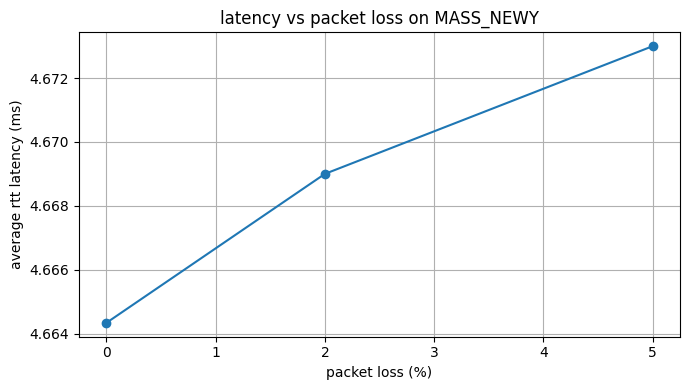

saved: latency_vs_loss_MASS_UCSD_0510_0530.png


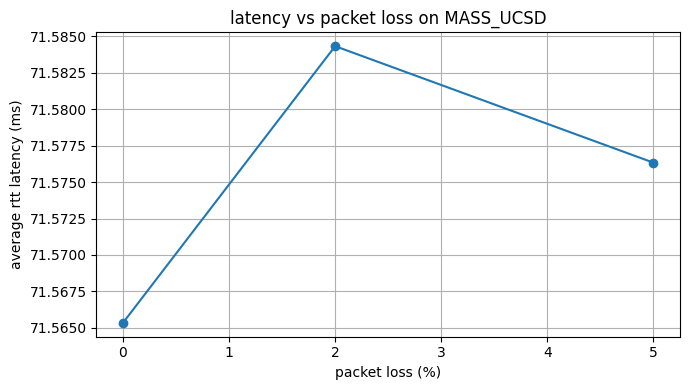

In [ ]:
# plot average rtt latency versus packet loss for each path

latency_summary_dataframe = clean_results_dataframe.groupby(
    ["path_name", "loss_percent"],
    as_index=False,
).agg(
    avg_latency_ms=("latency_ms", "mean"),
)  # average latency by path and loss

for path_name in latency_summary_dataframe["path_name"].unique():
    path_latency = latency_summary_dataframe[
        latency_summary_dataframe["path_name"] == path_name
    ]  # select one path

    plt.figure(figsize=(7, 4))

    # plot latency across loss levels
    plt.plot(
        path_latency["loss_percent"],
        path_latency["avg_latency_ms"],
        marker="o",
    )

    plt.xlabel("packet loss (%)")
    plt.ylabel("average rtt latency (ms)")
    plt.title(f"latency vs packet loss on {path_name}")
    plt.grid(True)
    plt.tight_layout()

    graph_file = f"latency_vs_loss_{path_name}_{timestamp}.png"
    plt.savefig(graph_file, dpi=300)

    print("saved:", graph_file)
    plt.show()

In [ ]:
def cleanup_path(path_config):  # remove packet loss and stop servers
    slice_object = slice_objects[path_config["path_name"]]

    client_node = slice_object.get_node(name="client")
    server_node = slice_object.get_node(name="server")

    client_interface_name = get_data_interface_name(client_node)

    clear_packet_loss(client_node, client_interface_name)   # remove packet loss rule
    stop_servers(server_node)   # stop tcp and quic servers


for path_config in path_configs:
    cleanup_path(path_config)  # clean each path

In [ ]:
# calculate throughput drop relative to each protocol's 0% loss baseline

baseline_dataframe = summary_dataframe[
    summary_dataframe["loss_percent"] == 0
][["path_name", "protocol", "avg_throughput_mbps"]]  # get baseline rows

# rename baseline column
baseline_dataframe = baseline_dataframe.rename(
    columns={"avg_throughput_mbps": "baseline_throughput_mbps"}
)  

# attach baseline to each row
degradation_dataframe = summary_dataframe.merge(
    baseline_dataframe,
    on=["path_name", "protocol"],
    how="left",
)

# calculate drop from baseline
degradation_dataframe["throughput_drop_percent"] = (
    (1 - degradation_dataframe["avg_throughput_mbps"] / degradation_dataframe["baseline_throughput_mbps"]) * 100
) 

# keep useful columns
degradation_dataframe = degradation_dataframe[
    [
        "path_name",
        "protocol",
        "loss_percent",
        "avg_throughput_mbps",
        "baseline_throughput_mbps",
        "throughput_drop_percent",
        "avg_latency_ms",
        "avg_tcp_retransmits",
        "trials",
    ]
]  

degradation_file = f"quic_tcp_fabric_degradation_summary_{timestamp}.csv"
degradation_dataframe.to_csv(degradation_file, index=False)

print("degradation summary:", degradation_file)
display(degradation_dataframe)

degradation summary: quic_tcp_fabric_degradation_summary_0510_0530.csv


,path_name,protocol,loss_percent,avg_throughput_mbps,baseline_throughput_mbps,throughput_drop_percent,avg_latency_ms,avg_tcp_retransmits,trials
0,MASS_NEWY,QUIC,0,119.719418,119.719418,0.000000,4.664333,NaN,3
1,MASS_NEWY,QUIC,2,13.517759,119.719418,88.708800,4.669000,NaN,3
2,MASS_NEWY,QUIC,5,7.489546,119.719418,93.744084,4.673000,NaN,3
3,MASS_NEWY,TCP,0,594.139940,594.139940,0.000000,4.664333,57.333333,3
4,MASS_NEWY,TCP,2,577.278088,594.139940,2.838027,4.669000,50.666667,3
5,MASS_NEWY,TCP,5,15.679411,594.139940,97.360990,4.673000,253.333333,3
6,MASS_UCSD,QUIC,0,55.477392,55.477392,0.000000,71.565333,NaN,3
7,MASS_UCSD,QUIC,2,1.085745,55.477392,98.042906,71.584333,NaN,3
8,MASS_UCSD,QUIC,5,0.629558,55.477392,98.865199,71.576333,NaN,3
9,MASS_UCSD,TCP,0,71.823998,71.823998,0.000000,71.565333,0.000000,3
